# Load Packages

In [2]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
# using Distributions
using LsqFit
using BlackBoxOptim
using LaTeXStrings
using JLD2
using KernelDensity
using XLSX
using Dates
using Statistics
# using Distributions
using OrdinaryDiffEq
using LsqFit
using BlackBoxOptim
using LaTeXStrings
using KernelDensity
using Polynomials 
using Trapz

# Extract Data

In [3]:
dDNP = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ProcessedData\\LacVsPyr_Hypersense_Reduced.csv", DataFrame));
plat = Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\LDHActivityAssey\\Results\\LDHActivityResults.csv", DataFrame));

In [4]:
ppDNP = [71.52456846326336, 149.72936537382074, 0.035641505051707635, -155.7168946583787, 0.7919342251656567]
ppPLA = [51.647244105077476, 7.486283267146228, 0.008937299958298018, -7.2952507331194445, 3.2552901271557353]

ss(t,p) = p[1].*(p[2].*exp.(-t.*p[3]).+p[4].*exp.(-t.*p[5]))


# nRMSE (Does not include the 0, since the low noise in that experiment has a really high effect, masking the rest of the experiments)
fftcDNP = ss(dDNP[:,1], ppDNP)
nRMSEDNP = sum(((transpose(dDNP[:,2])[2:end] - fftcDNP[2:end]).^2) ./ transpose(dDNP[:,3])[2:end].^2)/length(fftcDNP[2:end]) + log(5*log(length(fftcDNP[2:end])))

fftcPLA = ss(plat[:,1], ppPLA)
nRMSEPLA = sum(((transpose(plat[:,2])[2:end] - fftcPLA[2:end]).^2) ./ transpose(plat[:,3])[2:end].^2)/length(fftcPLA[2:end]) + log(5*log(length(fftcPLA[2:end])))

11.65037409321144

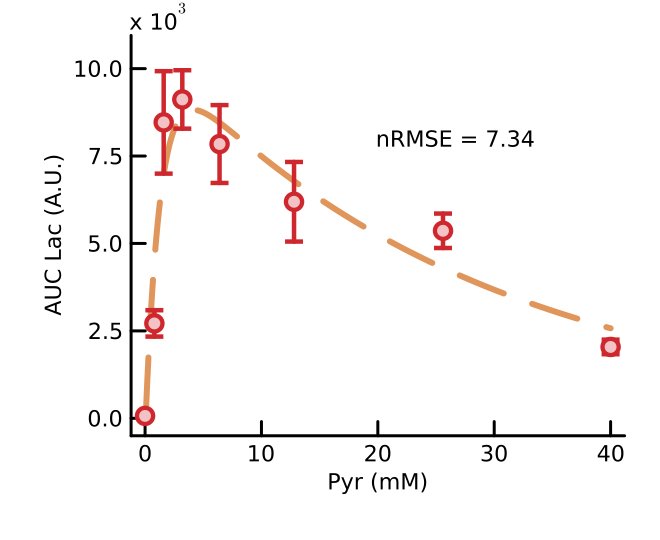

In [5]:
pp1 = plot(0.1:0.1:40, ss(0.1:0.1:40, ppDNP)./10^3, label="", colour="#e0955bff", linewidth = 2, ylim = (-0.5, maximum((dDNP[:,2].+dDNP[:,3])./10^3).+(maximum((dDNP[:,2].+dDNP[:,3])./10^3)*0.1)), 
    linestyle=:dash)

scatter!(dDNP[:,1], dDNP[:,2]./10^3, yerror = dDNP[:,3]./10^3,
        xlabel = "Pyr (mM)", ylabel = "AUC Lac (A.U.)", label = "", grid = false, markersize=3, markerstrokewidth=4, 
        linewidth=1.5, size = (110*2,90*2), xguidefontsize=round(25/5), yguidefontsize=round(25/5), tickfontsize=round(25/5), dpi = 300, 
        colour = "#f3c2c4ff", markerstrokecolor="#ce272dff")
        
annotate!(-1.3, 11.5, text("x 10"*L"^3",  :black, :left, 5))

annotate!(20, 8, text("nRMSE = "*string(round(nRMSEDNP, digits = 2)),  :black, :left, 5))

# savefig(pp1,"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure3Stuff\\LacVsPyrDat.svg")

display(pp1)

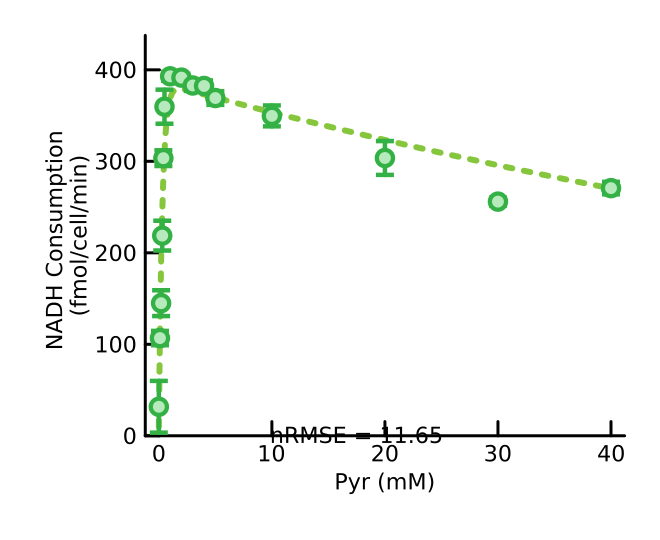

In [6]:
pp1 = plot(0:0.1:40, ss(0:0.1:40, ppPLA), label="", colour="#86c63cff", linewidth = 2, ylim = (0, maximum((plat[:,2].+plat[:,3])).+(maximum((plat[:,2].+plat[:,3]))*0.1)), 
    linestyle=:dot)

scatter!(plat[1:15,1], plat[1:15,2], yerror = plat[1:15,3],
        xlabel = "Pyr (mM)", ylabel = "NADH Consumption \n(fmol/cell/min)", label = "", grid = false, markersize=3, markerstrokewidth=4, 
        linewidth=1.5, size = (110*2,90*2), xguidefontsize=round(25/5), yguidefontsize=round(25/5), tickfontsize=round(25/5), dpi = 300, 
        colour = "#b6eabdff", markerstrokecolor="#33b144ff")
        

annotate!(10, 1, text("nRMSE = "*string(round(nRMSEPLA, digits = 2)),  :black, :left, 5))

# savefig(pp1,"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure3Stuff\\LacVsPyrDat.svg")

display(pp1)

# Combined Plot

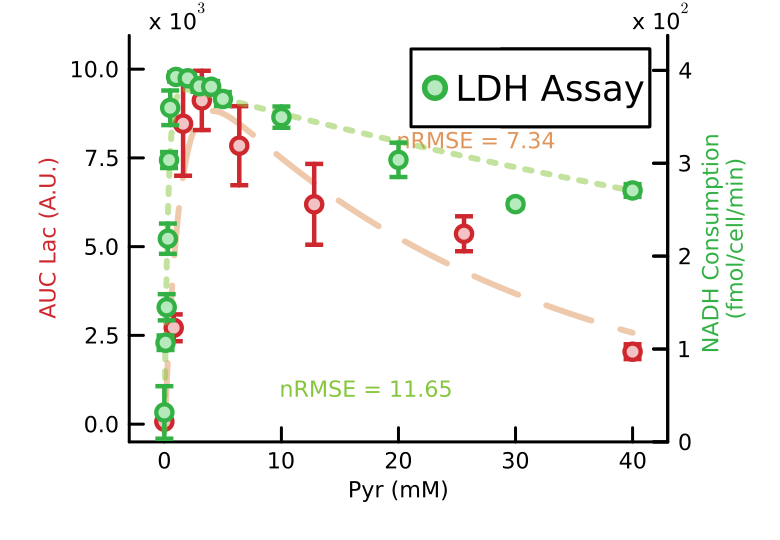

In [16]:
pp1 = plot(size = (130*2,90*2), xlims=(-3,43))

# dDNP EXPERIMENT

plot!(0.1:0.1:40, ss(0.1:0.1:40, ppDNP)./10^3, label="", colour="#e0955bff", linewidth = 2, ylim = (-0.5, maximum((dDNP[:,2].+dDNP[:,3])./10^3).+(maximum((dDNP[:,2].+dDNP[:,3])./10^3)*0.1)), 
    linestyle=:dash, alpha = 0.5)

scatter!(dDNP[:,1], dDNP[:,2]./10^3, yerror = dDNP[:,3]./10^3,
        xlabel = "Pyr (mM)", ylabel = "AUC Lac (A.U.)", label = "dDNP", grid = false, markersize=3, markerstrokewidth=4, 
        linewidth=1.5, xguidefontsize=round(25/5), yguidefontsize=round(25/5), tickfontsize=round(25/5), dpi = 300, 
        colour = "#f3c2c4ff", markerstrokecolor="#ce272dff", yguidefont = font("#ce272dff"))
        
annotate!(-1.3, 11.5, text("x 10"*L"^3",  :black, :left, 5))
annotate!(40, 11.5, text("x 10"*L"^2",  :black, :left, 5))


annotate!(20, 8, text("nRMSE = "*string(round(nRMSEDNP, digits = 2)),  "#e0955bff", :left, 5))
annotate!(10, 1, text("nRMSE = "*string(round(nRMSEPLA, digits = 2)),  "#86c63cff", :left, 5))

# LDH ASSEY EXPERIMENT

plot!(twinx(), 0:0.1:40, ss(0:0.1:40, ppPLA)./100, label="", colour="#86c63cff", linewidth = 2, ylim = (0, (maximum((plat[:,2].+plat[:,3])).+(maximum((plat[:,2].+plat[:,3]))*0.1))./100), 
    linestyle=:dot, xlims=(-3,43), yformatter=_->"", alpha = 0.5)


scatter!(twinx(), plat[1:15,1], plat[1:15,2]./100, yerror = plat[1:15,3]./100, ylim = (0, (maximum((plat[:,2].+plat[:,3])).+(maximum((plat[:,2].+plat[:,3]))*0.1))./100),
        xlabel = "", ylabel = "NADH Consumption \n(fmol/cell/min)", label = "LDH Assay", grid = false, markersize=3, markerstrokewidth=4, 
        linewidth=1.5, xguidefontsize=round(25/5), yguidefontsize=round(25/5), tickfontsize=round(25/5), dpi = 300, 
        colour = "#b6eabdff", markerstrokecolor="#33b144ff", xlims=(-3,43), yguidefont = font("#33b144ff"))



savefig(pp1,"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\Figure3Stuff\\LacVsPyrDat_LDHAssay_Tog.svg")

display(pp1)